# SI-26 Urdu OCR Project — Week 3
## Dataset Expansion, Urdu-Aware Tokenizer, and PyTorch `Dataset` / `DataLoader` Pipeline

**Programme:** Code Saviours ML/AI Internship — Batch SI-26
**Project:** Urdu OCR (Optical Character Recognition) Tool
**Week:** 3 of 5

---

### Notebook Overview

This notebook takes the Week 2 dataset and prepares it for model training in four stages:

| Stage | What happens | Why it matters |
|---|---|---|
| 1. Dataset Expansion | Generates additional synthetic Urdu text-line images and appends them to `labels.csv` | Grows the dataset toward the required size and adds variety in fonts/backgrounds |
| 2. Dataset Verification | Checks total image count, inspects category/source balance, and repairs any missing `split` values | Confirms the dataset is complete and correctly structured before training |
| 3. Tokenizer & Augmentation | Builds a **character-level Urdu tokenizer** and a training-only image augmentation pipeline | Character-level tokens let the decoder learn real Urdu patterns instead of arbitrary byte fragments; augmentation improves generalization to unseen photos |
| 4. Dataset / DataLoader | Wraps everything in a PyTorch `Dataset` and `DataLoader`, with visual and statistical sanity checks | Produces `train_loader` / `test_loader` ready for Week 4 model fine-tuning |

Run the cells in order from top to bottom.

---
## Step 0 — Setup: Mount Google Drive and Install Dependencies

`drive.mount()` connects this Colab session to Google Drive so that all files under
`/content/drive/MyDrive/...` become readable/writable, exactly as if they were local files.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Root folder for the project dataset (created in Week 1 / Week 2).
PROJECT_DIR = '/content/drive/MyDrive/Urdu_OCR_Project_v2'

os.chdir(PROJECT_DIR)

print('Current working directory:', os.getcwd())
print('Top-level contents of the project folder:', os.listdir(PROJECT_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory: /content/drive/MyDrive/Urdu_OCR_Project_v2
Top-level contents of the project folder: ['trocr-urdu-finetuned', 'week4_v2_training_loss.png', 'week4_v3_training_loss.png', 'trocr-urdu-finetuned-v3', 'week4_v4_training_loss.png', 'trocr-urdu-finetuned-v4', 'fonts', 'corpus', 'week4_checkpoints (1)', 'trocr-urdu-finetuned-v7', 'README_week5_draft.md', 'week4_checkpoints', 'data', 'week2_gap_analysis.csv', 'week2_word_recovery_rate.png', 'week2_text_length_by_source.png', 'labels.csv', 'raw']


### Install/Upgrade Required Libraries

In [2]:
# transformers   -> ViTImageProcessor / TrOCR components used to prepare model inputs
# torch          -> PyTorch, used for the Dataset/DataLoader classes and tensors
# torchvision    -> data augmentation transforms
# pillow (PIL)   -> opening, converting, and rendering images
# pandas         -> reading and manipulating labels.csv
# gdown          -> downloading shared files/folders from Google Drive
# matplotlib     -> dataset visualizations
# sentencepiece, protobuf -> tokenizer dependencies used by some Hugging Face models
!pip install -q --upgrade transformers torch torchvision pillow pandas gdown matplotlib sentencepiece protobuf

---
## Step 1 — Expand the Dataset with Synthetic Urdu Text-Line Images

To grow the dataset beyond what was manually collected, this step renders additional
Urdu text lines as standalone images and appends them to `labels.csv`. Text is sampled
from a public Urdu news-headline corpus, filtered down to short, single-line, and
topic-safe entries, then rendered using Nastaliq/Naskh fonts on a few plain
backgrounds to add visual variety.

In [3]:
import urllib.request

# --- Fonts used to render the synthetic text lines ---
os.makedirs('fonts', exist_ok=True)

FONT_URLS = {
    'fonts/NotoNastaliqUrdu.ttf':
        'https://raw.githubusercontent.com/google/fonts/main/ofl/notonastaliqurdu/NotoNastaliqUrdu%5Bwght%5D.ttf',
    'fonts/NotoNaskhArabic-Variable.ttf':
        'https://raw.githubusercontent.com/google/fonts/main/ofl/notonaskharabic/NotoNaskhArabic%5Bwght%5D.ttf',
}

for dest, url in FONT_URLS.items():
    if os.path.exists(dest):
        print(f'Already have {dest}, skipping')
        continue
    try:
        urllib.request.urlretrieve(url, dest)
        print(f'Downloaded {dest} ({os.path.getsize(dest) / 1024:.0f} KB)')
    except Exception as e:
        print(f'Could not download {dest}: {e}')

Already have fonts/NotoNastaliqUrdu.ttf, skipping
Already have fonts/NotoNaskhArabic-Variable.ttf, skipping


In [4]:
import tarfile, glob, urllib.error

# --- Text corpus used as the source of synthetic labels ---
os.makedirs('corpus', exist_ok=True)
corpus_url = 'https://raw.githubusercontent.com/mirfan899/Urdu/master/news/headlines.csv.tar.gz'
archive_path = 'corpus/headlines.csv.tar.gz'

try:
    urllib.request.urlretrieve(corpus_url, archive_path)
    with tarfile.open(archive_path) as tf:
        tf.extractall('corpus')
    matches = glob.glob('corpus/**/headlines.csv', recursive=True)
    if not matches:
        raise FileNotFoundError('headlines.csv not found inside the downloaded archive')
    headlines_csv = matches[0]
    print('Corpus ready:', headlines_csv)
except (urllib.error.URLError, tarfile.TarError, FileNotFoundError) as e:
    raise RuntimeError(
        f'Could not prepare the headlines corpus from {corpus_url}: {e}. '
        'Check the network connection before continuing.'
    ) from e

/tmp/ipykernel_9108/167472403.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall('corpus')


Corpus ready: corpus/headlines.csv


In [5]:
import pandas as pd

# Categories considered safe/neutral for a training dataset (politics and
# entertainment gossip headlines are excluded).
SAFE_CATEGORIES = ['science', 'health', 'weird news', 'sports']


def load_safe_headlines(csv_path: str, n_needed: int, seed: int = 42) -> list:
    """Sample a pool of short, single-line headlines from safe categories.

    Filters out politics/entertainment content, keeps line lengths in a range
    that renders well as a single text line (15-70 characters), removes rows
    with embedded newlines/tabs, and de-duplicates before sampling.
    """
    df = pd.read_csv(csv_path, sep='\t')
    df = df[df['category'].isin(SAFE_CATEGORIES)]
    pool = df['title'].dropna().astype(str).str.strip()
    pool = pool[(pool.str.len() >= 15) & (pool.str.len() <= 70)]
    pool = pool[~pool.str.contains(r'[\t\n\r]')]
    pool = pool.drop_duplicates()
    return pool.sample(n=min(n_needed, len(pool)), random_state=seed).tolist()

In [6]:
!pip uninstall -y pillow -q
!pip install pillow==10.4.0 -q

In [7]:
from PIL import Image, ImageDraw, ImageFont
import random

FONTS = {'nastaliq': 'fonts/NotoNastaliqUrdu.ttf', 'naskh': 'fonts/NotoNaskhArabic-Variable.ttf'}
BACKGROUNDS = [('white', (255, 255, 255)), ('cream', (250, 244, 227)), ('light_grey', (238, 238, 235))]


def render_line(text: str, font_path: str, font_size: int, bg_rgb: tuple, pad: int = 18) -> Image.Image:
    """Render a single line of right-to-left Urdu text as a standalone image.

    Uses Pillow's raqm-backed shaping (direction='rtl', language='ur') so that
    Urdu letterforms join and reorder correctly, instead of being drawn as
    isolated, left-to-right glyphs.
    """
    font = ImageFont.truetype(font_path, font_size)
    tmp = Image.new('RGB', (10, 10))
    d = ImageDraw.Draw(tmp)
    bbox = d.textbbox((0, 0), text, font=font, direction='rtl', language='ur')
    w, h = (bbox[2] - bbox[0]) + 2 * pad, (bbox[3] - bbox[1]) + 2 * pad
    img = Image.new('RGB', (w, h), bg_rgb)
    draw = ImageDraw.Draw(img)
    draw.text((w - pad, pad - bbox[1]), text, font=font, fill=(20, 20, 20),
               direction='rtl', language='ur', anchor='ra')
    return img

In [8]:
random.seed(42)

LABELS_PATH = os.path.join(PROJECT_DIR, 'labels.csv')
SYNTHETIC_DIR = os.path.join(PROJECT_DIR, 'raw', 'synthetic')
os.makedirs(SYNTHETIC_DIR, exist_ok=True)

N_SYNTH = 110  # number of new synthetic images to generate; adjust based on the audit in Step 2

synthetic_texts = load_safe_headlines(headlines_csv, N_SYNTH)
new_rows = []
for i, text in enumerate(synthetic_texts):
    font_name = random.choice(list(FONTS.keys()))
    image = render_line(text, FONTS[font_name], random.randint(34, 56), random.choice(BACKGROUNDS)[1])
    filename = f'synth_{i:04d}.jpg'
    image.save(os.path.join(SYNTHETIC_DIR, filename), quality=92)
    new_rows.append({
        'image': os.path.join('raw', 'synthetic', filename),
        'text': text,
        'source': 'synthetic',
        'split': None,
    })

new_labels_df = pd.DataFrame(new_rows)
print(f'Generated {len(new_labels_df)} new synthetic images')
new_labels_df.head()

Generated 110 new synthetic images


,image,text,source,split
0,raw/synthetic/synth_0000.jpg,مصباح الحق کی قیادت میں ون ڈے ٹیم کے 7 کھلاڑی ...,synthetic,None
1,raw/synthetic/synth_0001.jpg,ایشین کبڈی ورلڈ کپ غیرمعینہ مدت کے لیے ملتوی,synthetic,None
2,raw/synthetic/synth_0002.jpg,مائیکل کلارک کی توہم پرستی آسٹریلیا کی ناکامی...,synthetic,None
3,raw/synthetic/synth_0003.jpg,کوہلی نے محمد عامر کو خطرناک ترین بولر قرار دیدیا,synthetic,None
4,raw/synthetic/synth_0004.jpg,ون ڈے رینکنگ، سیریز میں جان لڑانے کا پاکستان ک...,synthetic,None


In [9]:
# Merge the newly generated synthetic rows into labels.csv, skipping any
# accidental duplicates by image path.
existing_labels_df = pd.read_csv(LABELS_PATH)
combined_labels_df = (
    pd.concat([existing_labels_df, new_labels_df], ignore_index=True)
    .drop_duplicates(subset=['image'])
)
combined_labels_df.to_csv(LABELS_PATH, index=False)
print(f'labels.csv: {len(existing_labels_df)} -> {len(combined_labels_df)} rows')

labels.csv: 3154 -> 3264 rows


---
## Step 2 — Verify the Dataset

Confirms the dataset has reached the target size, inspects its composition by
source, and repairs any rows that are missing a `train`/`test` split label.

In [10]:
def find_file(root_dir, filename):
    """Search every folder inside root_dir for a file named `filename`.

    Returns the full path to the first match, or None if it is not found.
    `followlinks=True` ensures Google Drive shortcuts/symlinked folders are
    also searched, not just regular folders.
    """
    for root, _, files in os.walk(root_dir, followlinks=True):
        if filename in files:
            return os.path.join(root, filename)
    return None


LABELS_CSV = find_file(PROJECT_DIR, 'labels.csv')
PROCESSED_LABELS_CSV = find_file(PROJECT_DIR, 'processed_labels.csv')

if LABELS_CSV is None:
    raise FileNotFoundError(f'labels.csv could not be found anywhere inside {PROJECT_DIR}.')

print('Found labels.csv at:', LABELS_CSV)
print('Found processed_labels.csv at:', PROCESSED_LABELS_CSV if PROCESSED_LABELS_CSV else 'not found (using labels.csv instead)')

if PROCESSED_LABELS_CSV:
    LABELS_CSV = PROCESSED_LABELS_CSV

labels_df = pd.read_csv(LABELS_CSV)
current_count = len(labels_df)
TARGET = 1000

print(f'\nTotal labeled images: {current_count}')
print(f'Target for Week 3: {TARGET}+ images')

if current_count >= TARGET:
    print(f'Requirement met: {current_count} >= {TARGET}.')
else:
    print(f'Only {current_count} images found — {TARGET - current_count} more are needed.')

Found labels.csv at: /content/drive/MyDrive/Urdu_OCR_Project_v2/labels.csv
Found processed_labels.csv at: not found (using labels.csv instead)

Total labeled images: 3264
Target for Week 3: 1000+ images
Requirement met: 3264 >= 1000.


### Inspecting Dataset Composition

In [11]:
print('Image count by source:')
print(labels_df['source'].value_counts(dropna=False))

print('\nImage count by train/test split:')
print(labels_df['split'].value_counts(dropna=False))

Image count by source:
source
synthetic               714
augmented_blur          618
augmented_brightness    598
augmented_rotation      596
utrset_real             400
signboards_synthetic    162
books_synthetic         150
manual_screenshot        26
Name: count, dtype: int64

Image count by train/test split:
split
train    2523
test      631
NaN       110
Name: count, dtype: int64


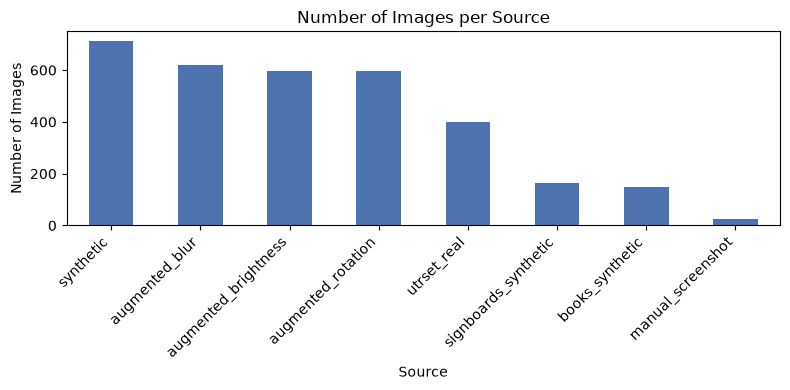

In [12]:
import matplotlib.pyplot as plt

source_counts = labels_df['source'].value_counts()

plt.figure(figsize=(8, 4))
source_counts.plot(kind='bar', color='#4C72B0')
plt.title('Number of Images per Source')
plt.xlabel('Source')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Fix Missing `split` Values

Some rows may lack a `split` value if they were added after the original
train/test split was created (for example, the synthetic rows generated in
Step 1). This assigns any such rows an 80/20 train/test split.

In [13]:
missing_split_mask = labels_df['split'].isna()
num_missing = missing_split_mask.sum()
print(f'Rows with a missing split value: {num_missing}')

if num_missing > 0:
    missing_rows = labels_df[missing_split_mask].sample(frac=1, random_state=42)
    cutoff = int(0.8 * len(missing_rows))

    train_fill_idx = missing_rows.index[:cutoff]
    test_fill_idx = missing_rows.index[cutoff:]

    labels_df.loc[train_fill_idx, 'split'] = 'train'
    labels_df.loc[test_fill_idx, 'split'] = 'test'

    print(f'Assigned {len(train_fill_idx)} rows to train, {len(test_fill_idx)} rows to test.')

    labels_df.to_csv(LABELS_CSV, index=False)
    print(f'Corrected labels.csv saved back to: {LABELS_CSV}')
else:
    print('No missing split values found — nothing to fix.')

print('\nUpdated split counts:')
print(labels_df['split'].value_counts(dropna=False))
print(f'Total: {len(labels_df)} (should equal train + test with no NaN remaining)')

Rows with a missing split value: 110
Assigned 88 rows to train, 22 rows to test.
Corrected labels.csv saved back to: /content/drive/MyDrive/Urdu_OCR_Project_v2/labels.csv

Updated split counts:
split
train    2611
test      653
Name: count, dtype: int64
Total: 3264 (should equal train + test with no NaN remaining)


### Resolve and Validate Every Image Path

Builds a filename index across the whole project folder, then resolves each
`labels.csv` path against it. This handles files that were moved or renamed
after `labels.csv` was first created.

In [14]:
file_index = {}
for root, _, files in os.walk(PROJECT_DIR, followlinks=True):
    for f in files:
        file_index.setdefault(f, os.path.join(root, f))

print(f'Indexed {len(file_index)} files across the project folder.')

Indexed 3693 files across the project folder.


In [15]:
def resolve_path(relative_path):
    """Resolve a path written in labels.csv to a real file on disk.

    First tries the path exactly as written (relative to PROJECT_DIR); if
    that fails, falls back to looking the file up by name only, using
    `file_index`. Returns None if the file cannot be found either way.
    """
    direct_path = os.path.join(PROJECT_DIR, relative_path)
    if os.path.exists(direct_path):
        return direct_path

    filename_only = os.path.basename(relative_path)
    return file_index.get(filename_only)


image_column = 'processed_image' if 'processed_image' in labels_df.columns else 'image'
print(f'Using column "{image_column}" as the image path source.')

labels_df['resolved_path'] = labels_df[image_column].apply(resolve_path)

missing_mask = labels_df['resolved_path'].isna()
print(f'\nTotal rows: {len(labels_df)}')
print(f'Successfully resolved: {(~missing_mask).sum()}')
print(f'Could not be found anywhere: {missing_mask.sum()}')

if missing_mask.sum() > 0:
    print(f'\n{missing_mask.sum()} entries could not be located and will be excluded from training.')
    labels_df = labels_df[~missing_mask].reset_index(drop=True)

print(f'\nFinal usable dataset size after path resolution: {len(labels_df)} images')

Using column "image" as the image path source.

Total rows: 3264
Successfully resolved: 3264
Could not be found anywhere: 0

Final usable dataset size after path resolution: 3264 images


---
## Step 3 — Build the Urdu Character Tokenizer

Instead of relying on TrOCR's built-in English tokenizer, this step builds a
character-level tokenizer directly from the Urdu text in the dataset. TrOCR's
default tokenizer is byte-level BPE trained on English text — it can
technically round-trip any UTF-8 text, but for Urdu it breaks every character
into multiple sub-byte fragments, which makes it much harder for the decoder
to learn real Urdu character patterns. A character-level vocabulary avoids
that problem entirely.

In [16]:
class UrduCharTokenizer:
    """Character-level tokenizer built from the Urdu text found in the dataset.

    Every distinct character is assigned its own token id, alongside four
    special tokens: padding, beginning-of-sequence, end-of-sequence, and
    unknown.
    """

    def __init__(self, texts, max_length=300):
        chars = set()
        for t in texts:
            chars.update(str(t))
        self.chars = sorted(chars)

        specials = ['<pad>', '<bos>', '<eos>', '<unk>']
        self.vocab = {tok: i for i, tok in enumerate(specials)}
        for ch in self.chars:
            self.vocab[ch] = len(self.vocab)
        self.inv_vocab = {i: tok for tok, i in self.vocab.items()}

        self.pad_token_id = self.vocab['<pad>']
        self.bos_token_id = self.vocab['<bos>']
        self.eos_token_id = self.vocab['<eos>']
        self.unk_token_id = self.vocab['<unk>']
        self.max_length = max_length

    def __len__(self):
        return len(self.vocab)

    def encode(self, text, max_length=None, padding='max_length'):
        max_length = max_length or self.max_length
        ids = [self.bos_token_id] + [self.vocab.get(ch, self.unk_token_id) for ch in str(text)] + [self.eos_token_id]
        ids = ids[:max_length]
        if padding == 'max_length':
            ids = ids + [self.pad_token_id] * (max_length - len(ids))
        return ids

    def decode(self, ids, skip_special_tokens=True):
        out = []
        for i in ids:
            i = int(i)
            if skip_special_tokens and i in (self.pad_token_id, self.bos_token_id, self.eos_token_id):
                continue
            out.append(self.inv_vocab.get(i, ''))
        return ''.join(out)


MAX_LEN = 300  # generous upper bound to accommodate longer, book-paragraph-style labels
urdu_tokenizer = UrduCharTokenizer(labels_df['text'].tolist(), max_length=MAX_LEN)

print('Urdu character vocabulary size:', len(urdu_tokenizer))

longest = labels_df['text'].str.len().max()
print(f'Longest label in dataset: {longest} characters (MAX_LEN={MAX_LEN} must stay above this)')

# Round-trip sanity check
sample_text = labels_df['text'].iloc[0]
sample_ids = urdu_tokenizer.encode(sample_text)
sample_decoded = urdu_tokenizer.decode(sample_ids)
print('\nOriginal  :', sample_text)
print('Round-trip:', sample_decoded)
print('Match:', sample_text.strip() == sample_decoded.strip())

Urdu character vocabulary size: 142
Longest label in dataset: 285 characters (MAX_LEN=300 must stay above this)

Original  : اردو زبان کو کئی ہندوستانی ریاستوں میں سرکاری حیثیت بھی حاصل ہے
Round-trip: اردو زبان کو کئی ہندوستانی ریاستوں میں سرکاری حیثیت بھی حاصل ہے
Match: True


### Data Augmentation Pipeline

Applies rotation, brightness/contrast jitter, and light blur — but only to
**training** rows. This simulates the kind of variation real unseen photos
have (slightly tilted, differently lit, not perfectly sharp), which helps the
model generalize beyond clean, synthetic renders.

In [17]:
from torchvision import transforms

train_augmentation = transforms.Compose([
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
])

print('Augmentation pipeline ready (applied only to rows where split == "train").')

Augmentation pipeline ready (applied only to rows where split == "train").


---
## Step 4 — PyTorch `Dataset` Class

Wraps `labels.csv` in a `torch.utils.data.Dataset`. Each sample returns:

- `pixel_values`: the image converted into the tensor format the TrOCR vision
  encoder expects, with training-split images augmented beforehand.
- `labels`: the ground-truth Urdu text, tokenized with the custom
  character-level `UrduCharTokenizer`.

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import ViTImageProcessor
from PIL import Image

image_processor = ViTImageProcessor.from_pretrained('microsoft/trocr-base-printed')


class UrduOCRDataset(Dataset):
    """Custom PyTorch Dataset for the SI-26 Urdu OCR project.

    Each sample consists of:
      - pixel_values: the image, converted into the numeric tensor format
        expected by the TrOCR vision encoder. Training-split images are
        augmented (rotation/brightness/blur) before conversion.
      - labels: the ground-truth Urdu text, tokenized with the
        character-level UrduCharTokenizer.
    """

    def __init__(self, dataframe, image_processor, tokenizer):
        self.data = dataframe.reset_index(drop=True)
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        print(f'UrduOCRDataset initialized with {len(self.data)} samples.')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # --- Image side ---
        image = Image.open(row['resolved_path']).convert('RGB')

        if row['split'] == 'train':
            image = train_augmentation(image)  # augmentation applies to training rows only

        encoding = self.image_processor(image, return_tensors='pt')
        pixel_values = encoding.pixel_values.squeeze()

        # --- Text side ---
        labels = self.tokenizer.encode(row['text'], max_length=MAX_LEN)
        labels = torch.tensor(labels)

        return {'pixel_values': pixel_values, 'labels': labels}

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

### Testing the `Dataset` Class

In [19]:
dataset = UrduOCRDataset(labels_df, image_processor, urdu_tokenizer)

sample = dataset[0]
print('Sample pixel_values shape:', sample['pixel_values'].shape)
print('Sample labels shape:', sample['labels'].shape)
print('\nDataset is working correctly.')
print(f'\nDataset contains {len(dataset)} images and loads correctly.')

UrduOCRDataset initialized with 3264 samples.
Sample pixel_values shape: torch.Size([3, 384, 384])
Sample labels shape: torch.Size([300])

Dataset is working correctly.

Dataset contains 3264 images and loads correctly.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


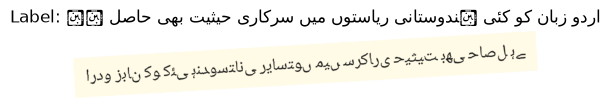

Original label     : اردو زبان کو کئی ہندوستانی ریاستوں میں سرکاری حیثیت بھی حاصل ہے
Decoded from tensor : اردو زبان کو کئی ہندوستانی ریاستوں میں سرکاری حیثیت بھی حاصل ہے
Match: True


In [20]:
# Visual sanity check: display the first image with its Urdu label as the
# title, and confirm the tokenized label decodes back into readable Urdu text.
first_row = labels_df.iloc[0]
image_to_show = Image.open(first_row['resolved_path']).convert('RGB')

decoded_text = urdu_tokenizer.decode(sample['labels'].tolist())

plt.figure(figsize=(6, 3))
plt.imshow(image_to_show)
plt.title(f"Label: {first_row['text']}")
plt.axis('off')
plt.show()

print('Original label     :', first_row['text'])
print('Decoded from tensor :', decoded_text)
print('Match:', first_row['text'].strip() == decoded_text.strip())

---
## Step 5 — Dataset Visualization

Before this dataset feeds into training, it is worth inspecting it directly
rather than relying on the counts above alone:

- **Category/source balance** — how many rows fall into each source, and whether any rows are missing a value entirely.
- **File availability** — how many rows still point to an image that cannot be resolved.
- **Text length distribution** — very short or very long lines behave differently during OCR training.
- **A visual sample grid** — actual images next to their ground-truth text, as a final check that labels match content.

This section only reads existing data; it does not modify anything.

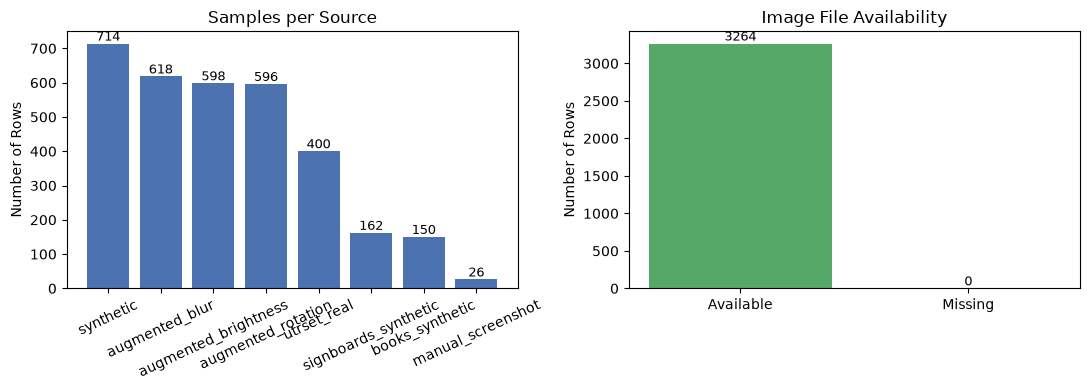

In [21]:
labels_df['_available'] = ~labels_df['resolved_path'].isna()

# dropna=False on purpose: a blank/missing source is a real data-quality
# issue and should show up as its own bar, not disappear silently.
source_counts_full = labels_df['source'].value_counts(dropna=False)
source_labels = ['(missing source)' if pd.isna(s) else s for s in source_counts_full.index]

availability_counts = labels_df['_available'].value_counts().reindex([True, False], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bar_colors = ['#C44E52' if lbl == '(missing source)' else '#4C72B0' for lbl in source_labels]
axes[0].bar(source_labels, source_counts_full.values, color=bar_colors)
axes[0].set_title('Samples per Source')
axes[0].set_ylabel('Number of Rows')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(source_counts_full.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

axes[1].bar(['Available', 'Missing'], availability_counts.values, color=['#55A868', '#C44E52'])
axes[1].set_title('Image File Availability')
axes[1].set_ylabel('Number of Rows')
for i, v in enumerate(availability_counts.values):
    axes[1].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

n_missing_source = labels_df['source'].isna().sum()
if n_missing_source:
    print(f'Note: {n_missing_source} row(s) in labels.csv have no source value — worth tracking down.')

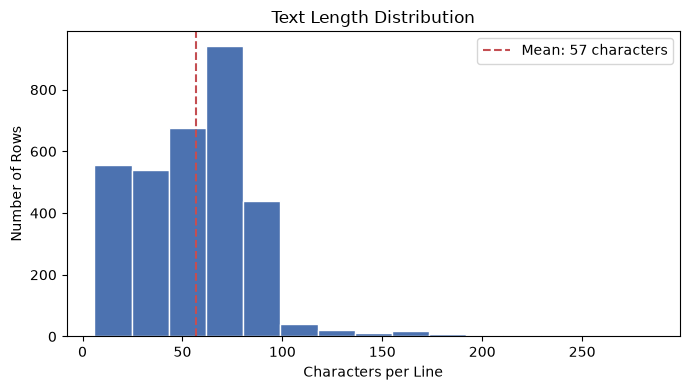

In [22]:
lengths = labels_df['text'].astype(str).str.len()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(lengths, bins=15, color='#4C72B0', edgecolor='white')
ax.axvline(lengths.mean(), color='#C44E52', linestyle='--', label=f'Mean: {lengths.mean():.0f} characters')
ax.set_title('Text Length Distribution')
ax.set_xlabel('Characters per Line')
ax.set_ylabel('Number of Rows')
ax.legend()
plt.tight_layout()
plt.show()

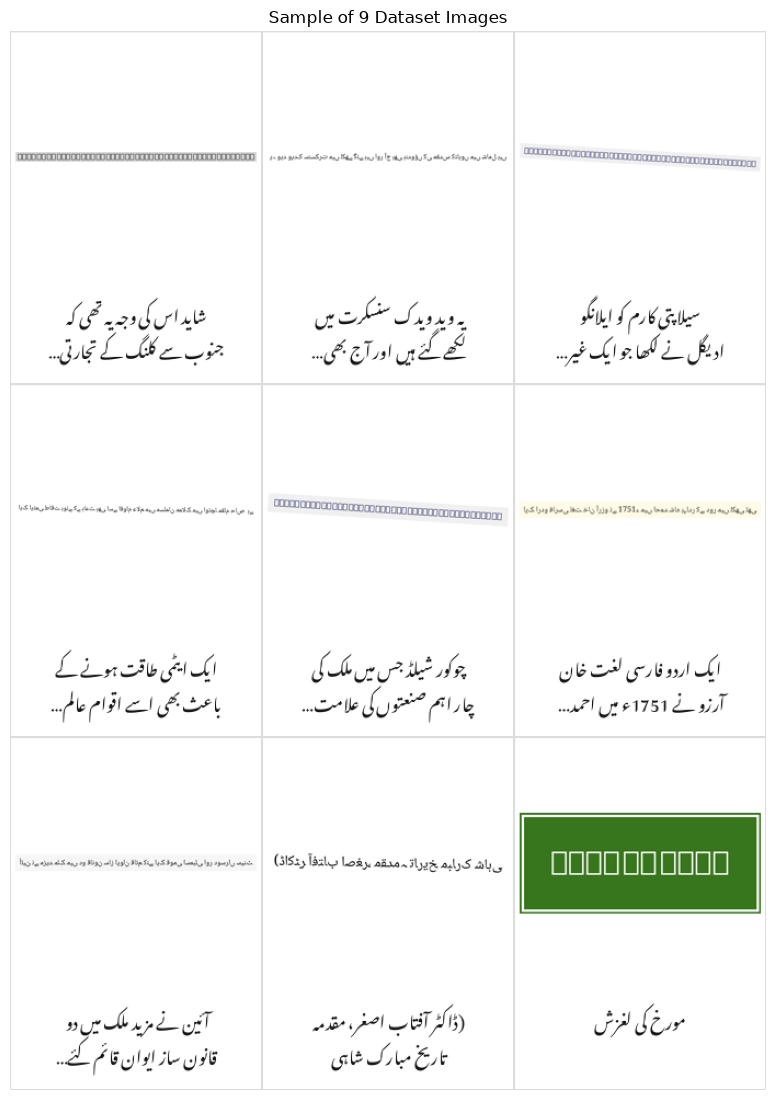

In [23]:
import textwrap


def show_sample_grid(data, n=9, cols=3, font_path=FONTS['nastaliq'],
                      thumb_size=230, caption_h=92, font_size=16):
    """Display a grid of sample images with their ground-truth text as captions.

    Captions are drawn with PIL using the same RTL/shaping setup as the
    synthetic image generation in Step 1, then handed to matplotlib as a
    single raster image — matplotlib's own text renderer does not shape
    Arabic-script text correctly, so it cannot draw the captions directly.
    """
    if len(data) == 0:
        print('No available images to sample from.')
        return

    sample_rows = data.sample(n=min(n, len(data)), random_state=0)
    n_cols = min(cols, len(sample_rows))
    n_rows = -(-len(sample_rows) // n_cols)
    cell_w, cell_h = thumb_size, thumb_size + caption_h
    line_h = int(font_size * 2.0)  # Nastaliq needs generous line spacing (diagonal flow)

    grid_img = Image.new('RGB', (n_cols * cell_w, n_rows * cell_h), (255, 255, 255))
    font = ImageFont.truetype(font_path, font_size)

    for i, (_, row) in enumerate(sample_rows.iterrows()):
        r, c = divmod(i, n_cols)
        thumb = Image.open(row['resolved_path']).convert('RGB')
        thumb.thumbnail((thumb_size - 10, thumb_size - 10))
        cell = Image.new('RGB', (cell_w, cell_h), (255, 255, 255))
        cell.paste(thumb, ((cell_w - thumb.width) // 2, (thumb_size - thumb.height) // 2))

        draw = ImageDraw.Draw(cell)
        wrapped = textwrap.wrap(str(row['text']), width=24)
        caption_lines = wrapped[:2]
        if len(wrapped) > 2:
            caption_lines[-1] = caption_lines[-1] + '…'
        for li, line in enumerate(caption_lines):
            bbox = draw.textbbox((0, 0), line, font=font, direction='rtl', language='ur')
            tw = bbox[2] - bbox[0]
            y = thumb_size + 6 + li * line_h
            draw.text(((cell_w + tw) / 2, y), line, font=font, fill=(20, 20, 20),
                       direction='rtl', language='ur', anchor='ra')
        draw.rectangle([0, 0, cell_w - 1, cell_h - 1], outline=(220, 220, 220))
        grid_img.paste(cell, (c * cell_w, r * cell_h))

    plt.figure(figsize=(n_cols * 3, n_rows * 3.7))
    plt.imshow(grid_img)
    plt.axis('off')
    plt.title(f'Sample of {len(sample_rows)} Dataset Images')
    plt.tight_layout()
    plt.show()


show_sample_grid(labels_df[labels_df['_available']], n=9)

---
## Step 6 — Recreate the Train/Test Split

Reuses the existing `split` column rather than generating a new random split,
so results stay consistent with the earlier analysis.

In [24]:
train_indices = labels_df[labels_df['split'] == 'train'].index.tolist()
test_indices = labels_df[labels_df['split'] == 'test'].index.tolist()

train_dataset = torch.utils.data.Subset(dataset, train_indices)
test_dataset = torch.utils.data.Subset(dataset, test_indices)

print(f'Training samples: {len(train_dataset)}')
print(f'Testing samples : {len(test_dataset)}')
print(f'Total           : {len(train_dataset) + len(test_dataset)} (should match dataset size above)')

Training samples: 2611
Testing samples : 653
Total           : 3264 (should match dataset size above)


---
## Step 7 — Build the `DataLoader`

Handles batching, shuffling (training set only), and multi-worker loading.

In [25]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

batch = next(iter(train_loader))

print('Batch pixel_values shape:', batch['pixel_values'].shape)
print('Batch labels shape:', batch['labels'].shape)
print(f'\nNumber of training batches per epoch: {len(train_loader)}')
print(f'Number of testing batches per epoch : {len(test_loader)}')
print('\nDataLoader is working correctly. This project is ready for Week 4 model training.')

Batch pixel_values shape: torch.Size([8, 3, 384, 384])
Batch labels shape: torch.Size([8, 300])

Number of training batches per epoch: 327
Number of testing batches per epoch : 82

DataLoader is working correctly. This project is ready for Week 4 model training.


---
## Summary

| Step | What was done | Result |
|---|---|---|
| Step 1 | Generated additional synthetic Urdu text-line images and merged them into `labels.csv` | Dataset grown with varied fonts/backgrounds |
| Step 2 | Verified dataset size, inspected source composition, fixed missing `split` values, and resolved every image path | Clean, verified dataset ready for loading |
| Step 3 | Built a custom character-level `UrduCharTokenizer` and a training-only augmentation pipeline | Real Urdu character tokens instead of byte fragments; simulated real-world photo variation |
| Step 4 | Built the `UrduOCRDataset` class and confirmed it loads image/label pairs correctly | Dataset validated with a round-trip decode check |
| Step 5 | Visualized source balance, file availability, text length distribution, and a sample image grid | Confirmed data quality before training |
| Step 6 | Reused the corrected train/test split | Train/test counts add up to the full dataset size |
| Step 7 | Built `DataLoader` objects for both splits | Batching and shuffling confirmed working |

This notebook produces everything (`train_loader`, `test_loader`, `urdu_tokenizer`)
needed for Week 4 model fine-tuning.